<a href="https://colab.research.google.com/github/Omarnagyafifi1/data-science-and-machine-learning-projects/blob/master/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas  as  pd
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics  import accuracy_score ,confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(2024)
np.random.seed(2024)

'''
seed() is essentially saying: "freeze the randomness so my experiment is reproducible and fair."
'''




'\nseed() is essentially saying: "freeze the randomness so my experiment is reproducible and fair."\n'

In [2]:
tf.__version__

'2.19.0'

In [3]:
(X_train_full,y_train_full),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train_full[12]# it is a gray scale

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  32,  60,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  85, 216, 144,  43,   0,   0,   0,   0,   0,   0,   0,  91,
         54,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,  27,
        172, 200, 182, 189, 197,   0,   0,   0,  12, 110, 130, 139, 127,
         66,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,  45,
        212, 180, 158, 213, 235,  92,  27, 103, 184, 193, 132,  43,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   1,   0,   0,   0,   0,   0,
        194, 222, 163, 163, 182, 239, 211, 164,  69,  25,   0,   0,   1,
          5,   0],
       [  0,   0,   0,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0,
         55, 244, 242, 229, 200, 216,  63,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  1,   0,   0,   1,   0,   0,  24, 117, 190,   0,   0,   0,   0,
          0, 157, 230, 226, 202, 206, 148,   0,   0,   3,  18,  30,  39,
         65,  48],
       [  1,   2,   1,   1,   0, 144, 197, 184, 206, 150,   0,   0,   0,
          0,   5,  94, 157, 189, 203, 243, 177, 108, 136, 149, 154, 150,
        145, 108],
       [  0,   0,   0,   0,   0, 101, 235, 197, 171, 230,  30,   0,   0,
          0,   0,  47, 200, 206, 148, 154, 109,  75,  54,  61,  61,  57,
         75,  54],
       [  6,  16,   1,   0,   0,   0, 190, 126,   0, 200, 101,   0,  29,
         85, 119, 127, 154, 101,  90,  97,  66, 118, 105, 121,  91,  94,
        122,  48],
       [ 41, 112, 113, 115, 106,  94, 197, 206, 114, 194, 255, 119, 123,
        118,  79,  86,  55, 108,  74,  74,  81,  57, 103,  54,  82,  86,
         83,  46],
       [ 29,  72,  34,  74,  59,  83, 100,  63,  96,  83, 114,  64,  70,
         63, 100,  69, 100,  91,  81,  87,  92,  94,  87, 115,  68,  70,
         96,  24],
       [ 20,  99,  90, 104,  86, 103,  82,  91,  48,  78,  64, 109,  92,
         79,  74,  95, 108,  91,  88,  95,  97,  75,  79, 100,  92,  96,
         97,  14],
       [  6,  97,  75,  91,  79,  90,  63,  94,  90,  91, 100,  72,  75,
         83,  81,  79,  55,  73,  48,  88,  81,  83,  68,  61,  69,  39,
         79,   2],
       [  0,  82, 115, 109, 109, 123,  78,  95,  92,  91, 105,  90, 110,
        117, 130, 132, 137, 141, 142, 128, 126, 151, 180, 170, 163, 162,
        114,   0],
       [  0,   0,   2,  39,  63,  85, 112, 101, 109, 105,  90,  94,  77,
         59,  47,  43,  19,   2,   0,   0,   0,   3,  25,  20,  27,  24,
          9,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [5]:
X_train_full.max(),X_train_full.min()

(np.uint8(255), np.uint8(0))

In [6]:
# we want all pixel to be  normalized [0,1] and it's type be float 32
'''For pixel values between 0 and 1, float32 precision is more than enough — you don't need float64.'''
X_train_full=(X_train_full/255).astype('float32')
X_test=(X_test/255).astype('float32')
#we will make target as int32
y_train_full=y_train_full.astype('int32')
y_test=y_test.astype('int32')



In [7]:
np.unique(y_train_full)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [8]:
X_train_full.max(),X_train_full.min()

(np.float32(1.0), np.float32(0.0))

In [9]:
(X_train_full.shape)#(6000->batch(samples))

(60000, 28, 28)

In [10]:
X_train,X_val,y_train,y_val=train_test_split(X_train_full,y_train_full,test_size=0.1,random_state=2024)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (54000, 28, 28)
Shape of y_train: (54000,)
Shape of X_val: (6000, 28, 28)
Shape of y_val: (6000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


In [11]:
# you need to flatten the input feature  we have to way one to flatten it before  entering the model or  in the nn model

Let's visualize the image and its target label together.

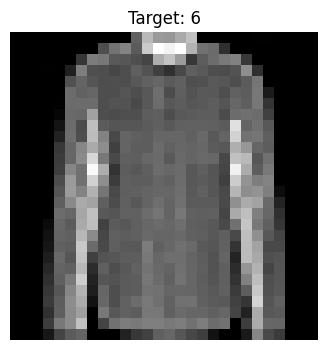

In [12]:
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Target: {y_train[0]}")
plt.axis('off')
plt.show()

In [13]:
y_target=pd.DataFrame(y_train,columns=['target'])
img_indicies={}
for i in range(len(np.unique(y_train))):
  img_indicies[i]=y_target[y_target['target']==i].index[0]

img_indicies

{0: np.int64(3),
 1: np.int64(8),
 2: np.int64(2),
 3: np.int64(6),
 4: np.int64(5),
 5: np.int64(1),
 6: np.int64(0),
 7: np.int64(11),
 8: np.int64(18),
 9: np.int64(7)}

In [14]:
class_names = [
    "T-shirt_top",   # Target: 0
    "Trouser",       # Target: 1
    "Pullover",      # Target: 2
    "Dress",         # Target: 3
    "Coat",          # Target: 4
    "Sandal",        # Target: 5
    "Shirt",         # Target: 6
    "Sneaker",       # Target: 7
    "Bag",           # Target: 8
    "Ankle_boot"     # Target: 9
]
# to show the name for each target we can use this
print(y_train[0])
class_names[y_train[0]]

6


'Shirt'

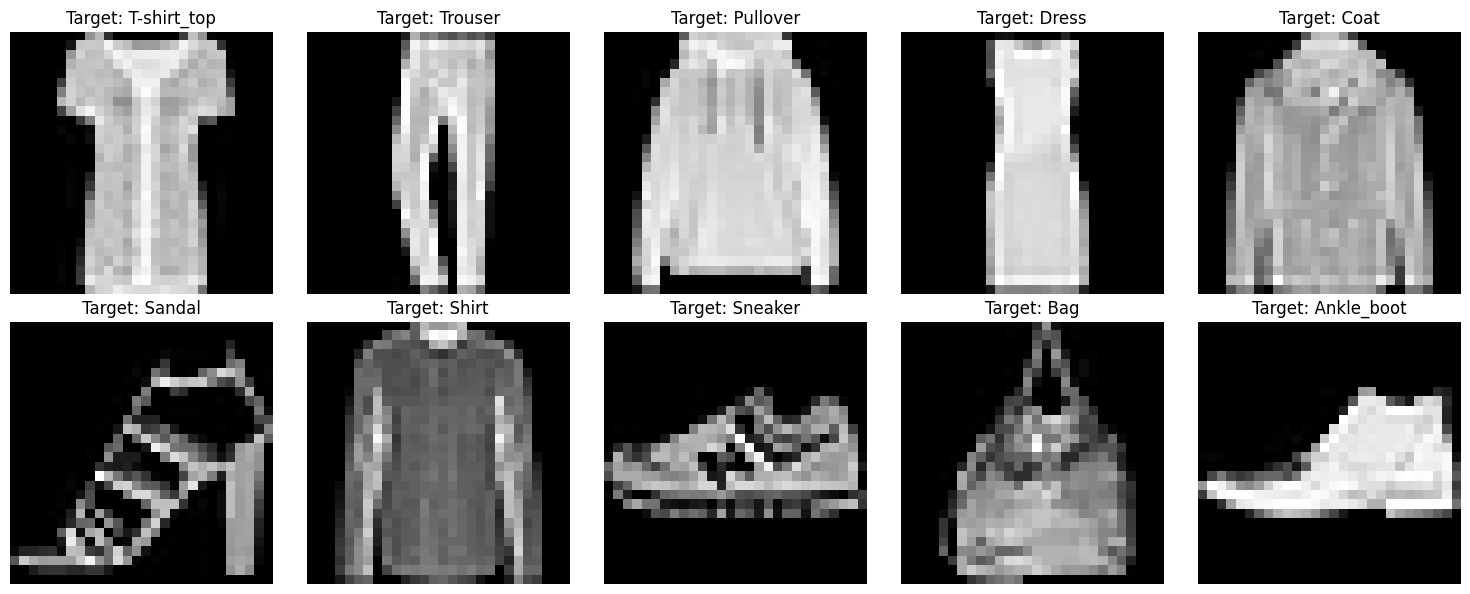

In [15]:
n_classes = len(img_indicies)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (target, idx) in enumerate(img_indicies.items()):
    axes[i].imshow(X_train[idx], cmap='gray')
    axes[i].set_title(f"Target: {class_names[target]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [18]:
model=tf.keras.models.Sequential(
                    [
                        tf.keras.layers.Flatten(input_shape=(28,28)),
                        tf.keras.layers.Dense(128,activation='relu'),
                        tf.keras.layers.Dense(64,activation='relu'),
                        tf.keras.layers.Dense(32,activation='relu'),
                        tf.keras.layers.Dense(10,activation='softmax')

                    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

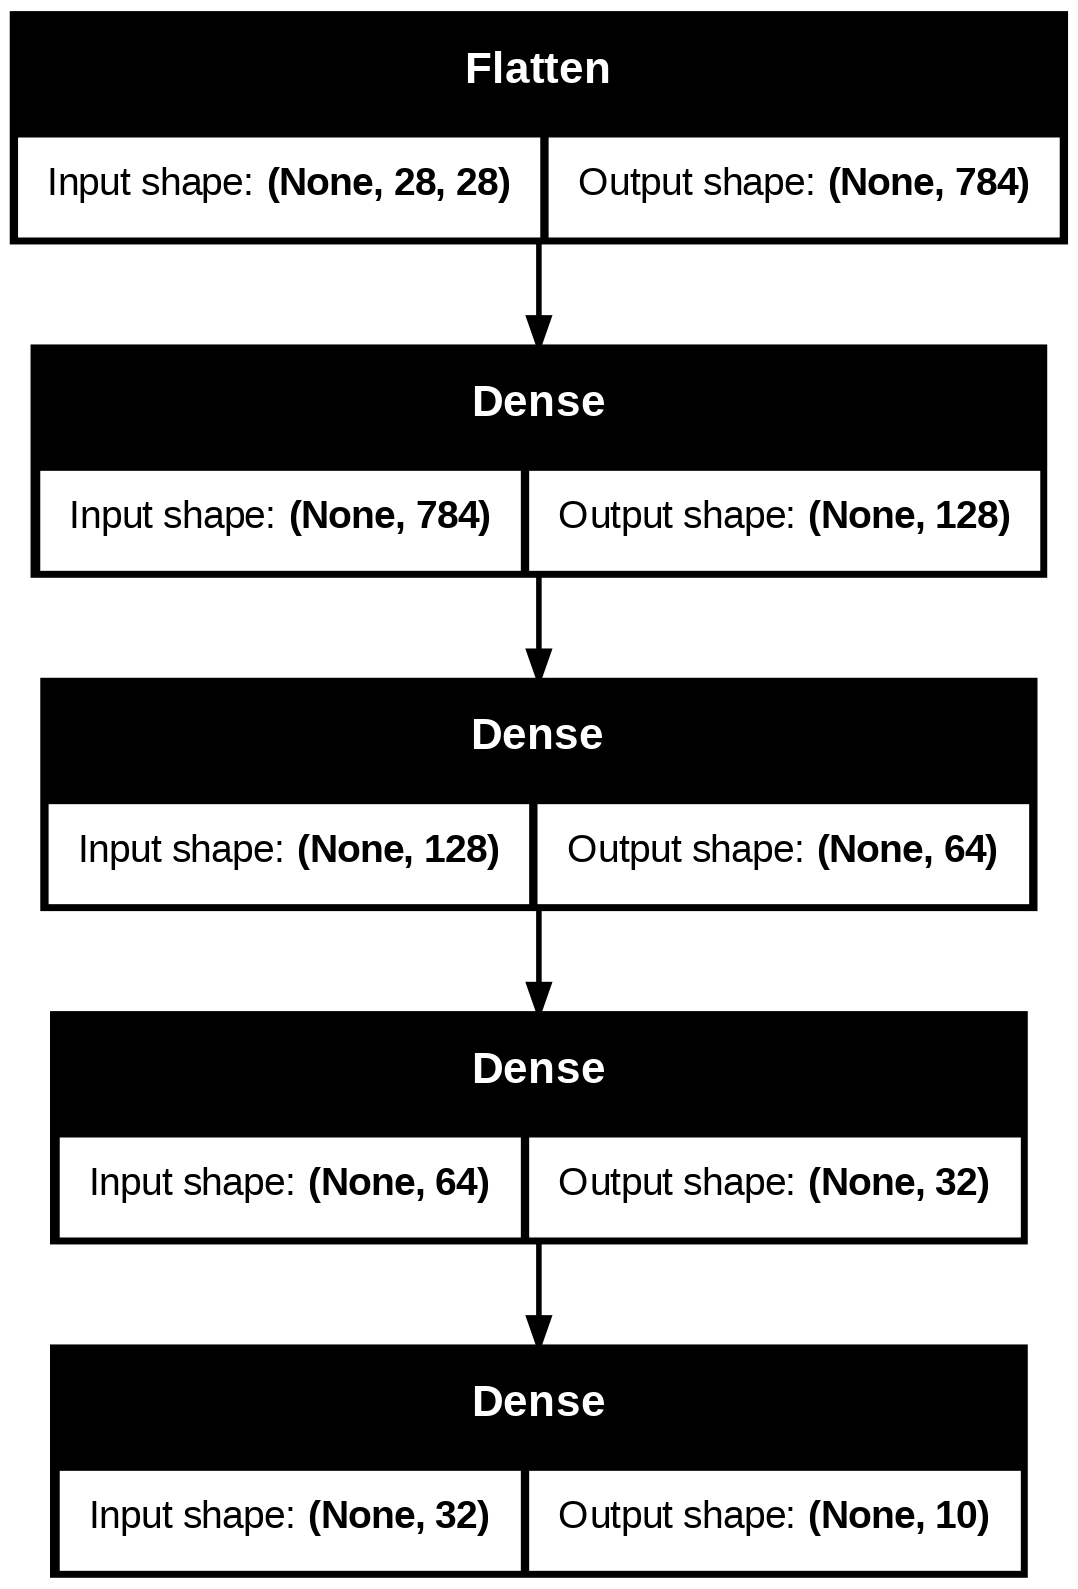

In [20]:
#plot model
tf.keras.utils.plot_model(model,show_shapes=True)

In [ ]:
# # to change in optimizer we use this
# tf.keras.optimizer.SGD()

#  loss -> multi class can be categorical_crossentropy if the output isnot 1d  like when making one hot encoding

# and sparse is  1d


In [30]:
from sklearn.utils.validation import validate_data
#
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']

)

er=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=model.fit(X_train,y_train,
          validation_data=(X_val,y_val)
          ,epochs=30,
          batch_size=32
          ,callbacks=[er])

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9133 - loss: 0.2313 - val_accuracy: 0.8892 - val_loss: 0.3430
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9157 - loss: 0.2238 - val_accuracy: 0.8817 - val_loss: 0.3557
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9204 - loss: 0.2142 - val_accuracy: 0.8903 - val_loss: 0.3434
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9215 - loss: 0.2084 - val_accuracy: 0.8863 - val_loss: 0.3700
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9236 - loss: 0.2005 - val_accuracy: 0.8810 - val_loss: 0.3910
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9250 - loss: 0.1986 - val_accuracy: 0.8833 - val_loss: 0.3818


In [31]:
history.history

{'accuracy': [0.9132592678070068,
  0.9157222509384155,
  0.9203518629074097,
  0.9214629530906677,
  0.9236111044883728,
  0.9249814748764038],
 'loss': [0.23126836121082306,
  0.22380319237709045,
  0.21420754492282867,
  0.20839764177799225,
  0.20050065219402313,
  0.19857801496982574],
 'val_accuracy': [0.8891666531562805,
  0.8816666603088379,
  0.890333354473114,
  0.8863333463668823,
  0.8809999823570251,
  0.8833333253860474],
 'val_loss': [0.34303605556488037,
  0.3557327389717102,
  0.3433520793914795,
  0.37004736065864563,
  0.3910152316093445,
  0.3817664682865143]}

In [32]:
model.save('model.keras')

In [36]:
model=tf.keras.models.load_model('model.keras')